### Let's build a Transformer, from scratch

Designed by: [Tirtharaj Dash](https://tirtharajdash.github.io); with assistance from: [claude.ai](claude.ai)

We will build a **Transformer** (Vaswani et al., NeurIPS 2017) completely from scratch in PyTorch -- one component at a time. We will first introduce each component with conceptual details, and then code it up in the following cell.

We will consider a number sequence reversal task to demonstrate the transformer methodology. We will train an *encoder–decoder* Transformer to reverse a sequence of integers. The encoder will take the input, a sequence of numbers, learn a *representation*, and then it will use that representation in its decoder (as input) to output a reversed sequence. This is a very simple task, designed specifically for our lecture; although most of the concepts you will study, in detail, in the Deep Learning course.

Here is an example:

- **Input** : `[3, 1, 4, 1, 5, 9]`
- **Output**: `[9, 5, 1, 4, 1, 3]`

**Reference**: Vaswani et al., *Attention is All You Need*, NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)

In [15]:
#Libraries go here.

import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

#Let's seed everything; although this is still incomplete!
torch.manual_seed(7)
random.seed(7)
np.random.seed(7)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.8.0+cu129
Device          : cuda


**Vocabulary and Tokenisation**

We work with a small integer vocabulary ($0–9$) plus three special tokens.

| Index | Token | Role |
|-------|-------|------|
| 0–9   | `0`–`9` | Source / target digits |
| 10    | `<BOS>` | Beginning-of-sequence (prepended to decoder input) |
| 11    | `<EOS>` | End-of-sequence (appended to decoder target) |
| 12    | `<PAD>` | Padding (not used in this fixed-length task, included for generality) |

Total vocabulary size $|V| = 13$.

In [16]:
VOCAB_SIZE  = 10   # source tokens: integers 0..9
BOS_IDX     = 10   # begin-of-sequence
EOS_IDX     = 11   # end-of-sequence
PAD_IDX     = 12   # padding
TOTAL_VOCAB = 13   # total vocabulary size

idx2tok = {i: str(i) for i in range(VOCAB_SIZE)}
idx2tok[BOS_IDX] = '<BOS>'
idx2tok[EOS_IDX] = '<EOS>'
idx2tok[PAD_IDX] = '<PAD>'

def decode(indices):
    """Convert a list of token indices to readable strings."""
    return [idx2tok[i] for i in indices]

# Example
print(decode([3, 1, 4, BOS_IDX, EOS_IDX, PAD_IDX]))

['3', '1', '4', '<BOS>', '<EOS>', '<PAD>']


Let's define our sequence reversal task.

*Defn.*: Given a source sequence $\mathbf{x} = (x_1, x_2, \ldots, x_T)$ of integers sampled uniformly from $\{0,\ldots,9\}$, the target is its reversal $\mathbf{y} = (x_T, x_{T-1}, \ldots, x_1)$.

**Encoder–decoder format**
During training with **teacher forcing**, the decoder receives:

- **Decoder input** $y_{\text{in}}$: `[<BOS>, y_1, y_2, ..., y_T]`  
- **Decoder target** $y_{\text{out}}$: `[y_1, y_2, ..., y_T, <EOS>]`

At each position $t$, the model predicts $y_t$ given the encoder output and the ground-truth prefix $y_{<t}$ (teacher forcing). The loss is cross-entropy summed over all positions.


In [17]:
SEQ_LEN = 10   # source sequence length

def generate_pair(seq_len=SEQ_LEN):
    src = [random.randint(0, VOCAB_SIZE - 1) for _ in range(seq_len)]
    tgt = src[::-1]
    return src, tgt


class ReverseDataset(Dataset):
    def __init__(self, n: int = 4000, seq_len: int = SEQ_LEN):
        self.pairs = [generate_pair(seq_len) for _ in range(n)]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_t    = torch.tensor(src,               dtype=torch.long)
        tgt_in   = torch.tensor([BOS_IDX] + tgt,   dtype=torch.long)
        tgt_out  = torch.tensor(tgt + [EOS_IDX],   dtype=torch.long)
        return src_t, tgt_in, tgt_out


def make_loaders(n_train=3200, n_val=800, batch_size=64):
    train_ds = ReverseDataset(n=n_train)
    val_ds   = ReverseDataset(n=n_val)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)
    return train_dl, val_dl


train_loader, val_loader = make_loaders()
src_batch, tgt_in_batch, tgt_out_batch = next(iter(train_loader))

print(f"src shape       : {src_batch.shape}")     # (64, 6)
print(f"tgt_in shape    : {tgt_in_batch.shape}")  # (64, 7)  BOS + 6 tokens
print(f"tgt_out shape   : {tgt_out_batch.shape}") # (64, 7)  6 tokens + EOS
print()
print(f"Example src     : {src_batch[0].tolist()}")
print(f"Example tgt_in  : {decode(tgt_in_batch[0].tolist())}")
print(f"Example tgt_out : {decode(tgt_out_batch[0].tolist())}")


src shape       : torch.Size([64, 10])
tgt_in shape    : torch.Size([64, 11])
tgt_out shape   : torch.Size([64, 11])

Example src     : [1, 7, 4, 0, 9, 3, 1, 9, 2, 5]
Example tgt_in  : ['<BOS>', '5', '2', '9', '1', '3', '9', '0', '4', '7', '1']
Example tgt_out : ['5', '2', '9', '1', '3', '9', '0', '4', '7', '1', '<EOS>']


**Token embedding**

Each token index $t$ is mapped to a dense vector:
$$\mathbf{e}_t = \sqrt{d_{\text{model}}} \cdot W_{\text{emb}}[t] \quad W_{\text{emb}} \in \mathbb{R}^{|V| \times d_{\text{model}}}$$
Scaling by $\sqrt{d_{\text{model}}}$ keeps embedding magnitudes comparable to the positional encoding magnitudes (Vaswani et al., 2017).

**Sinusoidal positional encoding**

Attention is **permutation-equivariant**: it has no built-in notion of order. We add a fixed positional signal to each token embedding:
$$\tilde{\mathbf{x}}_t = \mathbf{e}_t + \mathrm{PE}(t)$$
where
$$\mathrm{PE}(t,\, 2i) = \sin\!\left(\frac{t}{10000^{2i/d_{\text{model}}}}\right), \quad \mathrm{PE}(t,\, 2i{+}1) = \cos\!\left(\frac{t}{10000^{2i/d_{\text{model}}}}\right)$$
for $i = 0, 1, \ldots, d_{\text{model}}/2 - 1$.

**Some properties**:
- Each position has a unique encoding.
- Nearby positions have similar encodings (smooth frequency structure).
- $\mathrm{PE}(t+k)$ is a linear function of $\mathrm{PE}(t)$ — relative positions are linearly representable.
- No learned parameters.

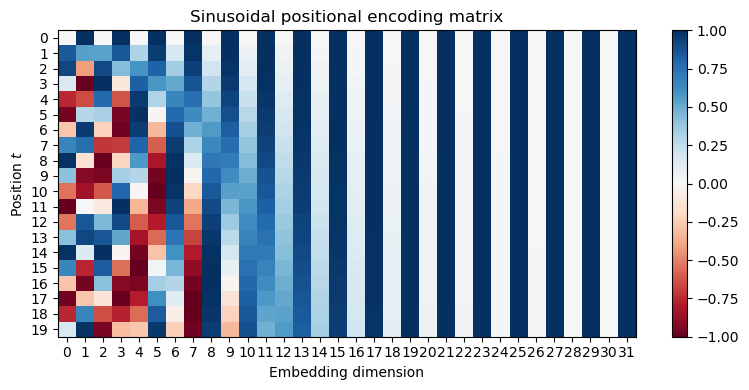

In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)                          # (max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)                  # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )                                                             # (d_model/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))                  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (batch, seq_len, d_model)"""
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.scale = math.sqrt(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embed(x) * self.scale


# Visualise the PE matrix
def visualise_pe(d_model=32, max_len=20):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len).unsqueeze(1)
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(pe.numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
    ax.set_xlabel('Embedding dimension')
    ax.set_ylabel('Position $t$')
    ax.set_title('Sinusoidal positional encoding matrix')
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(max_len))
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    #plt.savefig('pe_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()

visualise_pe()

**Scaled Dot-Product Attention**

Given query matrix $Q \in \mathbb{R}^{n \times d_k}$, key matrix $K \in \mathbb{R}^{m \times d_k}$, and value matrix $V \in \mathbb{R}^{m \times d_v}$ (rows are token vectors):

$$\boxed{\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V}$$

**Computing steps**:
1. **Raw scores**: $S = QK^\top \in \mathbb{R}^{n \times m}$; entry $S_{ij} = \mathbf{q}_i \cdot \mathbf{k}_j$ measures how much query $i$ matches key $j$.
2. **Scale**: divide by $\sqrt{d_k}$. For random unit vectors, $\mathbf{q}\cdot\mathbf{k} \sim \mathcal{N}(0, d_k)$; without scaling, large $d_k$ pushes softmax into near-zero-gradient saturation.
3. **Mask** (optional): add $-\infty$ to positions that should not be attended to; these become 0 after softmax.
4. **Normalise**: $A = \mathrm{softmax}(S/\sqrt{d_k})$; rows sum to 1; $A_{ij} \in [0,1]$.
5. **Aggregate**: output $= AV \in \mathbb{R}^{n \times d_v}$; each row is a convex combination of value vectors, weighted by attention.


In [34]:
def scaled_dot_product_attention(
    Q:    torch.Tensor,
    K:    torch.Tensor,
    V:    torch.Tensor,
    mask: torch.Tensor = None
):
    """
    Scaled dot-product attention.

    Args
    ----
    Q, K : (batch, heads, seq,   d_k)
    V    : (batch, heads, seq_k, d_v)
    mask : bool tensor, True -> masked out (-inf before softmax)

    Returns
    -------
    output  : (batch, heads, seq_q, d_v)
    weights : (batch, heads, seq_q, seq_k)
    """
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)   # (B,H,n,m)

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)
    output  = torch.matmul(weights, V)
    return output, weights


# Sanity check
B, H, S, dk = 2, 4, 5, 16
Q_ = torch.randn(B, H, S, dk)
K_ = torch.randn(B, H, S, dk)
V_ = torch.randn(B, H, S, dk)
out_, w_ = scaled_dot_product_attention(Q_, K_, V_)
print(f"Output shape       : {out_.shape}")          # (2, 4, 5, 16)
print(f"Weights shape      : {w_.shape}")            # (2, 4, 5, 5)
print(f"Weights row sum    : {w_[0, 0, 0].sum().item():.6f}")  # must be 1.0

Output shape       : torch.Size([2, 4, 5, 16])
Weights shape      : torch.Size([2, 4, 5, 5])
Weights row sum    : 1.000000


**Multi-Head Attention**

A single attention head computes one type of query–key relationship. Multi-head attention runs $h$ independent heads in parallel, each projecting into a lower-dimensional subspace, then concatenates and projects back:

$$\mathrm{head}_r = \mathrm{Attention}(QW_r^Q,\; KW_r^K,\; VW_r^V), \quad r = 1, \ldots, h$$

$$\boxed{\mathrm{MultiHead}(Q,K,V) = \mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h)\, W^O}$$

**Dimensions**: $W_r^Q, W_r^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $W_r^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$, $W^O \in \mathbb{R}^{h d_v \times d_{\text{model}}}$.

With $d_k = d_v = d_{\text{model}}/h$, total FLOPs $\approx$ one single full-dimensional head.

**Why multiple heads?** Each head can specialise: one may capture token co-occurrence, another positional proximity, another syntactic dependency. This has been empirically verified (Clark et al., ACL 2019).

In [35]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, h: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by h"
        self.h   = h
        self.d_k = d_model // h

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        """
        query : (B, seq_q, d_model)
        key   : (B, seq_k, d_model)
        value : (B, seq_k, d_model)
        Returns: output (B, seq_q, d_model), weights (B, h, seq_q, seq_k)
        """
        B = query.size(0)

        def project(W, x):
            # (B, seq, d_model) -> (B, h, seq, d_k)
            return W(x).view(B, -1, self.h, self.d_k).transpose(1, 2)

        Q = project(self.W_Q, query)
        K = project(self.W_K, key)
        V = project(self.W_V, value)

        ctx, weights = scaled_dot_product_attention(Q, K, V, mask)

        # Concat heads: (B, h, seq_q, d_k) -> (B, seq_q, d_model)
        ctx    = ctx.transpose(1, 2).contiguous().view(B, -1, self.h * self.d_k)
        output = self.W_O(ctx)
        return output, weights


# Sanity check
mha = MultiHeadAttention(d_model=64, h=8)
x   = torch.randn(2, 5, 64)
out, w = mha(x, x, x)
print(f"MHA output : {out.shape}")   # (2, 5, 64)
print(f"MHA weights: {w.shape}")     # (2, 8, 5, 5)

MHA output : torch.Size([2, 5, 64])
MHA weights: torch.Size([2, 8, 5, 5])


**Masks**

Two types of mask are needed:

**Padding mask**: marks `<PAD>` tokens so they are never attended to.
$$M^{\text{pad}}_{ij} = \mathbb{1}[k_j = \text{PAD}]$$

**Causal (look-ahead) mask**: prevents decoder position $i$ from attending to any position $j > i$.
$$M^{\text{causal}}_{ij} = \mathbb{1}[j > i]$$
Implemented as the strict upper triangle of a $T\times T$ matrix. Entries that are masked are set to $-\infty$ before softmax so they contribute zero to the weighted sum.

In the **decoder**:
- Self-attention uses causal mask (+ padding mask if applicable).
- Cross-attention uses only the source padding mask (decoder attends over all encoder positions).


In [7]:
def make_pad_mask(seq: torch.Tensor, pad_idx: int = PAD_IDX) -> torch.Tensor:
    """
    Returns bool tensor of shape (B, 1, 1, seq_len).
    True where token == PAD_IDX; broadcastable over (B, heads, seq_q, seq_k).
    """
    return (seq == pad_idx).unsqueeze(1).unsqueeze(2)


def make_causal_mask(seq_len: int, device: torch.device = torch.device('cpu')) -> torch.Tensor:
    """
    Returns bool tensor of shape (1, 1, seq_len, seq_len).
    True in strict upper triangle (j > i): position i cannot see position j > i.
    """
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()
    return mask.unsqueeze(0).unsqueeze(0)


# Visualise causal mask for seq_len=5
cm = make_causal_mask(5).squeeze().int()
print("Causal mask (1 = blocked, 0 = visible):")
print(cm)
# Row i: can attend to columns 0..i only (True/1 means blocked)


Causal mask (1 = blocked, 0 = visible):
tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)


**Encoder Block**:

One encoder layer applies two sub-layers, each wrapped with a **residual connection** and **layer normalisation**:

$$\mathbf{Z}^{(\ell)} = \mathrm{LayerNorm}\!\bigl(\mathbf{H}^{(\ell-1)} + \mathrm{MHA}(\mathbf{H}^{(\ell-1)})\bigr)$$
$$\mathbf{H}^{(\ell)} = \mathrm{LayerNorm}\!\bigl(\mathbf{Z}^{(\ell)} + \mathrm{FFN}(\mathbf{Z}^{(\ell)})\bigr)$$

**Feed-forward network (FFN)**: applied independently and identically to each token position:
$$\mathrm{FFN}(\mathbf{z}) = W_2\,\mathrm{ReLU}(W_1\mathbf{z} + \mathbf{b}_1) + \mathbf{b}_2, \quad W_1 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}},\; W_2 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$$
Standard: $d_{\text{ff}} = 4 \times d_{\text{model}}$.

**Layer normalisation**: normalises across the feature dimension per token:
$$\mathrm{LN}(\mathbf{z}) = \frac{\mathbf{z} - \mu}{\sqrt{\sigma^2+\epsilon}} \odot \boldsymbol{\gamma} + \boldsymbol{\beta}$$
where $\mu, \sigma^2$ are the mean and variance of $\mathbf{z}$'s elements, and $\boldsymbol{\gamma}, \boldsymbol{\beta}$ are learned.

**Residual connections** ensure that gradients flow directly from the loss to every layer, preventing vanishing gradients.


In [36]:
class FeedForward(nn.Module):
    """Position-wise two-layer MLP: d_model -> d_ff -> d_model."""
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


class EncoderBlock(nn.Module):
    """
    One Transformer encoder layer (Pre-LN).
    Residual + LayerNorm around each sub-layer.
    """
    def __init__(self, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h, dropout)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.drop1     = nn.Dropout(dropout)
        self.drop2     = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, src_mask: torch.Tensor = None):
        """x: (B, src_len, d_model)"""
        # Sub-layer 1: multi-head self-attention
        x2, _ = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), src_mask)
        x     = x + self.drop1(x2)
        # Sub-layer 2: position-wise FFN
        x     = x + self.drop2(self.ffn(self.norm2(x)))
        return x


# Sanity check
enc_blk = EncoderBlock(d_model=64, h=8, d_ff=256)
h_in    = torch.randn(2, 6, 64)
h_out   = enc_blk(h_in)
print(f"EncoderBlock input : {h_in.shape}")
print(f"EncoderBlock output: {h_out.shape}")   # same shape

EncoderBlock input : torch.Size([2, 6, 64])
EncoderBlock output: torch.Size([2, 6, 64])


**Decoder Block**:

The decoder has **three** sub-layers per block:

$$\mathbf{Z}_1 = \mathrm{LN}\bigl(\mathbf{H}_{\text{dec}} + \mathrm{MaskedMHA}(\mathbf{H}_{\text{dec}})\bigr)$$
$$\mathbf{Z}_2 = \mathrm{LN}\bigl(\mathbf{Z}_1 + \mathrm{CrossMHA}(\mathbf{Z}_1,\, \mathbf{H}_{\text{enc}},\, \mathbf{H}_{\text{enc}})\bigr)$$
$$\mathbf{H}'_{\text{dec}} = \mathrm{LN}\bigl(\mathbf{Z}_2 + \mathrm{FFN}(\mathbf{Z}_2)\bigr)$$

**Sub-layer 1: Masked self-attention**: the causal mask prevents position $i$ from attending to $j > i$. During training all positions are processed in parallel; the mask enforces left-to-right generation.

**Sub-layer 2: Cross-attention**: queries $Q$ come from the decoder ($\mathbf{Z}_1$), while keys $K$ and values $V$ come from the encoder output $\mathbf{H}_{\text{enc}}$. This is the mechanism by which the decoder "reads" the source sequence at each generation step.

**Sub-layer 3: FFN**: same position-wise MLP as in the encoder.


In [37]:
class DecoderBlock(nn.Module):
    """
    One Transformer decoder layer (Pre-LN).
    Three sub-layers: masked self-attn, cross-attn, FFN.
    """
    def __init__(self, d_model: int, h: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, h, dropout)
        self.cross_attn = MultiHeadAttention(d_model, h, dropout)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.norm3      = nn.LayerNorm(d_model)
        self.drop1      = nn.Dropout(dropout)
        self.drop2      = nn.Dropout(dropout)
        self.drop3      = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        """
        x       : (B, tgt_len, d_model)   decoder input
        enc_out : (B, src_len, d_model)   encoder output
        tgt_mask: causal mask (B,1,tgt_len,tgt_len)
        src_mask: padding mask (B,1,1,src_len)
        Returns: updated x, cross-attention weights (B,h,tgt_len,src_len)
        """
        # Sub-layer 1: masked self-attention
        x2, _        = self.self_attn(self.norm1(x), self.norm1(x), self.norm1(x), tgt_mask)
        x            = x + self.drop1(x2)
        # Sub-layer 2: cross-attention  (Q from decoder, K/V from encoder)
        x2, cross_w  = self.cross_attn(self.norm2(x), enc_out, enc_out, src_mask)
        x            = x + self.drop2(x2)
        # Sub-layer 3: FFN
        x            = x + self.drop3(self.ffn(self.norm3(x)))
        return x, cross_w


# Sanity check
dec_blk = DecoderBlock(d_model=64, h=8, d_ff=256)
tgt_in  = torch.randn(2, 7, 64)
enc_out = torch.randn(2, 6, 64)
out, cw = dec_blk(tgt_in, enc_out)
print(f"DecoderBlock output      : {out.shape}")    # (2, 7, 64)
print(f"Cross-attention weights  : {cw.shape}")     # (2, 8, 7, 6)
print(f"Cross-attn weights sum   : {cw[0,0,0].sum().item():.6f}")  # 1.0


DecoderBlock output      : torch.Size([2, 7, 64])
Cross-attention weights  : torch.Size([2, 8, 7, 6])
Cross-attn weights sum   : 1.000000


This is what we have discussed so far.

<img src="enc_dec_fig.png" width="50%"/>

**Full Encoder–Decoder Transformer**

Stack $N$ encoder blocks and $N$ decoder blocks, then project decoder output to vocabulary logits.

```
src  -->  [TokenEmbed + PE]  -->  Encoder x N  -->  enc_out
tgt  -->  [TokenEmbed + PE]  -->  Decoder x N  (cross-attn on enc_out)  -->  Linear  -->  softmax
```

**Output at each decoder step $t$**:
$$p(y_t \mid y_{<t}, \mathbf{x};\,\theta) = \mathrm{softmax}(W_{\text{out}}\, \mathbf{h}_t)$$
where $\mathbf{h}_t$ is the final decoder hidden state at position $t$.

**Loss** (cross-entropy, summed over positions, averaged over batch):
$$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N}\sum_{t=1}^{T}\log p(y_t^{(n)} \mid y_{<t}^{(n)}, \mathbf{x}^{(n)};\,\theta)$$

**Weight initialisation**: Xavier uniform for all weight matrices (Glorot & Bengio, 2010), which keeps gradient norms stable at initialisation.


In [45]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size : int   = TOTAL_VOCAB,
        d_model    : int   = 64,
        h          : int   = 4,
        d_ff       : int   = 256,
        N          : int   = 3,
        max_len    : int   = 64,
        dropout    : float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.src_embed = TokenEmbedding(vocab_size, d_model)
        self.tgt_embed = TokenEmbedding(vocab_size, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        self.encoder = nn.ModuleList(
            [EncoderBlock(d_model, h, d_ff, dropout) for _ in range(N)]
        )
        self.decoder = nn.ModuleList(
            [DecoderBlock(d_model, h, d_ff, dropout) for _ in range(N)]
        )
        self.out_norm   = nn.LayerNorm(d_model)
        self.out_linear = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def encode(self, src, src_mask):
        x = self.pos_enc(self.src_embed(src))
        for layer in self.encoder:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.pos_enc(self.tgt_embed(tgt))
        cross_w = None
        for layer in self.decoder:
            x, cross_w = layer(x, enc_out, tgt_mask, src_mask)
        return x, cross_w

    def forward(self, src, tgt_in):
        """
        src    : (B, src_len)
        tgt_in : (B, tgt_len)   BOS + target[:-1]
        Returns: logits (B, tgt_len, vocab_size), cross_w (B, h, tgt_len, src_len)
        """
        src_mask  = make_pad_mask(src).to(src.device)
        tgt_mask  = make_causal_mask(tgt_in.size(1), device=tgt_in.device)
        enc_out   = self.encode(src, src_mask)
        dec_out, cross_w = self.decode(tgt_in, enc_out, tgt_mask, src_mask)
        logits    = self.out_linear(self.out_norm(dec_out))
        return logits, cross_w


# Instantiate and inspect
model = Transformer(d_model=64, h=4, d_ff=256, N=3).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")

src_ex  = src_batch[:2].to(DEVICE)
tin_ex  = tgt_in_batch[:2].to(DEVICE)
logits, cw = model(src_ex, tin_ex)
print(f"Logits shape         : {logits.shape}")    # (2, 7, 13)
print(f"Cross-attn shape     : {cw.shape}")        # (2, 4, 7, 6)


Trainable parameters : 350,541
Logits shape         : torch.Size([2, 11, 13])
Cross-attn shape     : torch.Size([2, 4, 11, 10])


**Let's train**

**Optimiser**: Adam with $\beta_1=0.9$, $\beta_2=0.98$, $\epsilon=10^{-9}$ (as in Vaswani et al.).  
**Gradient clipping**: clip global $\ell_2$ norm to 1.0 to prevent exploding gradients.  
**LR schedule**: `ReduceLROnPlateau` halves the LR when validation loss plateaus.  
**Loss**: cross-entropy with `ignore_index=PAD_IDX` so padding positions do not contribute.


Epoch   1  train 2.2811  val 1.8984
Epoch   5  train 1.3295  val 0.8707
Epoch  10  train 0.7142  val 0.2248
Epoch  15  train 0.4266  val 0.0654
Epoch  20  train 0.2540  val 0.0150
Epoch  25  train 0.1527  val 0.0064
Epoch  30  train 0.0943  val 0.0033
Epoch  35  train 0.0646  val 0.0010
Epoch  40  train 0.0499  val 0.0009


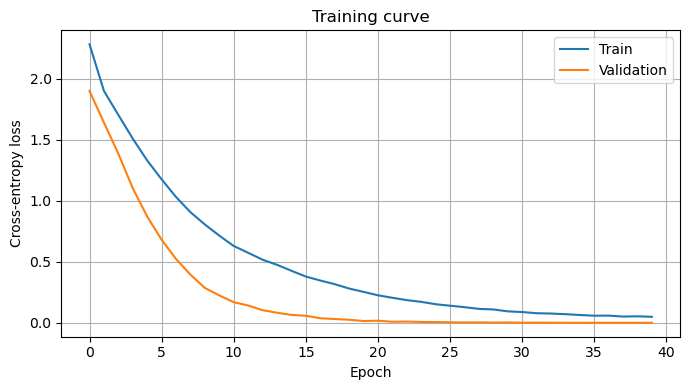

In [46]:
def train_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        logits, _ = model(src, tgt_in)
        loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.view(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            logits, _ = model(src, tgt_in)
            loss = criterion(logits.view(-1, logits.size(-1)), tgt_out.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)


def run_training(model, n_epochs=40, lr=3e-4, device=DEVICE):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )
    train_losses, val_losses = [], []
    for epoch in range(1, n_epochs + 1):
        tr  = train_epoch(model, train_loader, optimizer, criterion, device)
        val = eval_epoch(model,  val_loader,   criterion,            device)
        scheduler.step(val)
        train_losses.append(tr)
        val_losses.append(val)
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}  train {tr:.4f}  val {val:.4f}")
    return train_losses, val_losses


model = Transformer(d_model=64, h=4, d_ff=256, N=3).to(DEVICE)
train_losses, val_losses = run_training(model, n_epochs=40)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Training curve')
ax.legend()
ax.grid(True)
plt.tight_layout()
#plt.savefig('training_curve.png', dpi=100, bbox_inches='tight')
plt.show()


**Inference: Greedy Autoregressive Decoding**

At inference time, target tokens are not available, so we generate them **one at a time**:

1. Encode the source sequence once: $\mathbf{H}_{\text{enc}} = \mathrm{Encoder}(\mathbf{x})$.
2. Initialise decoder input with `<BOS>`.
3. At each step $t$:
   - Run the decoder on the current sequence $y_{1:t}$.
   - Take the **argmax** of the logit at position $t$ (greedy decoding).
   - Append the predicted token to $y_{1:t}$.
4. Stop when `<EOS>` is predicted or `max_len` is reached.

This is $O(T)$ sequential steps at inference, but fully parallel during training (teacher forcing).

**Alternative decoding strategies** (not implemented here): beam search, nucleus (top-$p$) sampling, temperature scaling.


In [47]:
@torch.no_grad()
def greedy_decode(model, src: torch.Tensor, max_len: int = SEQ_LEN + 2, device=DEVICE):
    """
    Greedy autoregressive decoding for a single source sequence.

    Args
    ----
    src     : (1, src_len)  source token indices
    max_len : maximum number of tokens to generate

    Returns
    -------
    generated   : list of predicted token indices (BOS and EOS stripped)
    attn_weights: cross-attention weights from the last decoder layer
                  shape (1, h, tgt_len, src_len) for visualisation
    """
    model.eval()
    src = src.to(device)

    src_mask = make_pad_mask(src).to(device)
    enc_out  = model.encode(src, src_mask)

    tgt_seq  = torch.tensor([[BOS_IDX]], dtype=torch.long, device=device)
    last_attn = None

    for _ in range(max_len):
        tgt_len  = tgt_seq.size(1)
        tgt_mask = make_causal_mask(tgt_len, device=device)
        dec_out, cross_w = model.decode(tgt_seq, enc_out, tgt_mask, src_mask)
        logits   = model.out_linear(model.out_norm(dec_out))  # (1, tgt_len, vocab)
        next_tok = logits[:, -1, :].argmax(dim=-1)            # (1,)
        last_attn = cross_w
        tgt_seq  = torch.cat([tgt_seq, next_tok.unsqueeze(0)], dim=1)
        if next_tok.item() == EOS_IDX:
            break

    generated = tgt_seq[0, 1:].tolist()   # strip BOS
    if EOS_IDX in generated:
        generated = generated[:generated.index(EOS_IDX)]
    return generated, last_attn


def evaluate_accuracy(model, n=500, device=DEVICE):
    """Sequence-level accuracy: correct only if every token matches."""
    correct = 0
    for _ in range(n):
        src, tgt = generate_pair()
        src_t    = torch.tensor([src], dtype=torch.long)
        pred, _  = greedy_decode(model, src_t, device=device)
        if pred == tgt:
            correct += 1
    return correct / n


# Run evaluation
acc = evaluate_accuracy(model, n=500)
print(f"Sequence-level accuracy (n=500): {acc*100:.1f}%")

# Qualitative examples
print("\nInference examples:")
for _ in range(6):
    src_ex, tgt_ex = generate_pair()
    src_t  = torch.tensor([src_ex], dtype=torch.long)
    pred, _ = greedy_decode(model, src_t)
    status  = "CORRECT" if pred == tgt_ex else "WRONG  "
    print(f"  [{status}]  src: {src_ex}   tgt: {tgt_ex}   pred: {pred}")

Sequence-level accuracy (n=500): 100.0%

Inference examples:
  [CORRECT]  src: [9, 4, 0, 7, 5, 2, 3, 3, 4, 5]   tgt: [5, 4, 3, 3, 2, 5, 7, 0, 4, 9]   pred: [5, 4, 3, 3, 2, 5, 7, 0, 4, 9]
  [CORRECT]  src: [6, 0, 6, 1, 4, 1, 3, 4, 5, 3]   tgt: [3, 5, 4, 3, 1, 4, 1, 6, 0, 6]   pred: [3, 5, 4, 3, 1, 4, 1, 6, 0, 6]
  [CORRECT]  src: [5, 5, 4, 5, 7, 7, 4, 3, 9, 8]   tgt: [8, 9, 3, 4, 7, 7, 5, 4, 5, 5]   pred: [8, 9, 3, 4, 7, 7, 5, 4, 5, 5]
  [CORRECT]  src: [8, 8, 5, 6, 3, 1, 9, 7, 9, 5]   tgt: [5, 9, 7, 9, 1, 3, 6, 5, 8, 8]   pred: [5, 9, 7, 9, 1, 3, 6, 5, 8, 8]
  [CORRECT]  src: [5, 3, 7, 0, 0, 9, 5, 7, 5, 8]   tgt: [8, 5, 7, 5, 9, 0, 0, 7, 3, 5]   pred: [8, 5, 7, 5, 9, 0, 0, 7, 3, 5]
  [CORRECT]  src: [7, 2, 6, 3, 0, 7, 6, 7, 3, 5]   tgt: [5, 3, 7, 6, 7, 0, 3, 6, 2, 7]   pred: [5, 3, 7, 6, 7, 0, 3, 6, 2, 7]


#### Let's inspect: Attention Weight Visualisation

We plot the **cross-attention weights** from the last decoder layer for a single head.

Row $t$ of the heatmap shows where the decoder was looking in the source sequence when generating output token $t$.

For the reversal task, a well-trained model should show a **reverse-diagonal** pattern: output token $t$ corresponds to source token $T - t$.


src : [6, 4, 3, 5, 0, 6, 3, 0, 3, 7]
tgt : [7, 3, 0, 3, 6, 0, 5, 3, 4, 6]
pred: [7, 3, 0, 3, 6, 0, 5, 3, 4, 6]



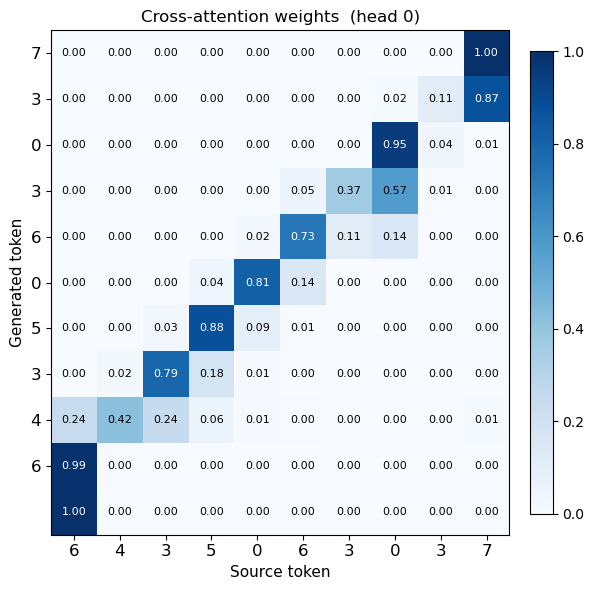

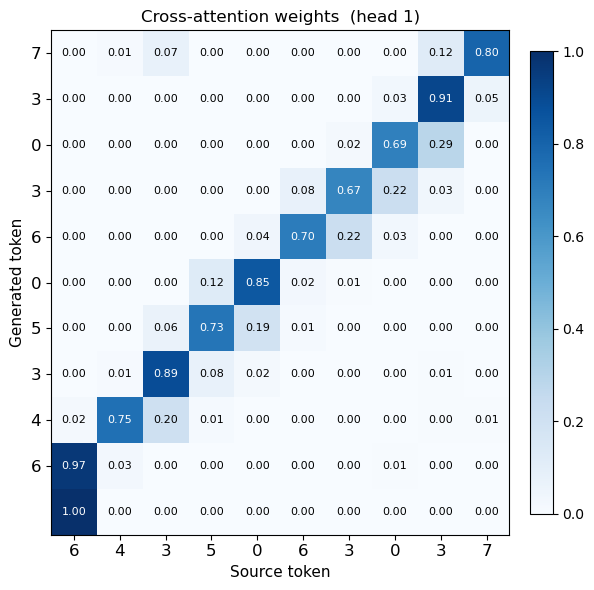

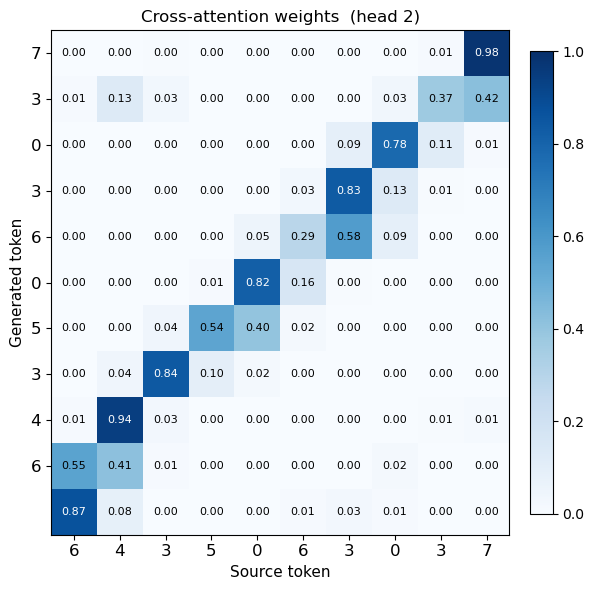

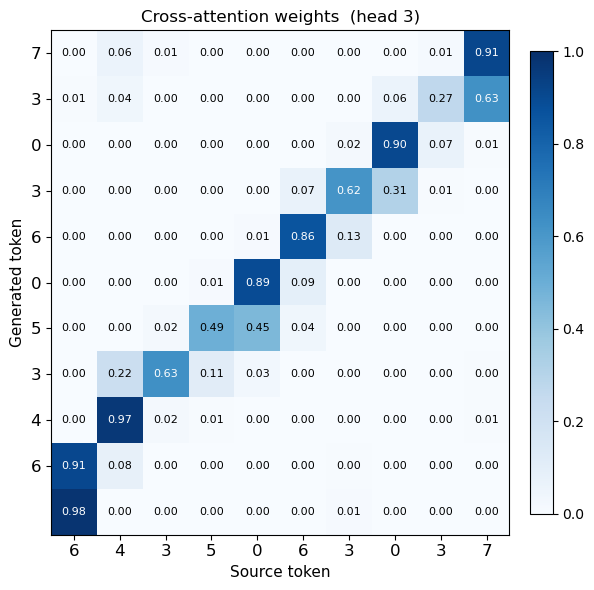

In [48]:
def plot_attention(attn_weights, src_tokens, tgt_tokens, head=0):
    """
    attn_weights : (1, h, tgt_len, src_len) from greedy_decode
    src_tokens   : list of source token strings
    tgt_tokens   : list of predicted token strings
    """
    if attn_weights is None:
        print("No attention weights.")
        return

    w = attn_weights[0, head].cpu().float().numpy()  # (tgt_len, src_len)

    fig, ax = plt.subplots(figsize=(max(5, 0.5*len(src_tokens) + 1),
                                    max(5, 0.5*len(tgt_tokens) + 1)))
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, fontsize=12)
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_yticklabels(tgt_tokens, fontsize=12)
    ax.set_xlabel('Source token', fontsize=11)
    ax.set_ylabel('Generated token', fontsize=11)
    ax.set_title(f'Cross-attention weights  (head {head})', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Annotate cells with values
    for i in range(w.shape[0]):
        for j in range(w.shape[1]):
            ax.text(j, i, f'{w[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if w[i,j] < 0.6 else 'white')
    plt.tight_layout()
    #plt.savefig('attention.png', dpi=100, bbox_inches='tight')
    plt.show()


# Plot for one example
src_ex, tgt_ex = generate_pair()
src_t = torch.tensor([src_ex], dtype=torch.long)
pred, attn_w = greedy_decode(model, src_t)

src_strs = [str(t) for t in src_ex]
pred_strs = [str(t) for t in pred] if pred else ['?']

print(f"src : {src_ex}")
print(f"tgt : {tgt_ex}")
print(f"pred: {pred}")
print()

for head_idx in range(min(4, attn_w.size(1))):
    plot_attention(attn_w, src_strs, pred_strs, head=head_idx)

#### Time for some homework

1. Change `SEQ_LEN` from 6 to 10. Retrain. Does accuracy drop? How many epochs does it take to recover?
2. Set `dropout=0.0` and retrain. Plot the loss curves. What do you observe compared to before?
3. Print the attention weights for a correctly decoded example. Which source position does each output token attend to most? Does it match the expected reverse-diagonal pattern?
4. Replace the reversal task with a **sorting task**: target is the source sorted in ascending order. Does the same architecture learn it? How does accuracy compare?
5. Remove positional encoding (comment out `+ self.pe` in `PositionalEncoding.forward`). Retrain. What happens and why?
6. Replace greedy decoding with **beam search** (beam width $k=3$). Does sequence accuracy improve?
7. Rewrite the model as a **decoder-only** Transformer: remove the encoder and feed source + target as one concatenated sequence with a separator token. Compare parameter count and accuracy.
8. Replace sinusoidal PE with a **learned positional embedding** (`nn.Embedding(max_len, d_model)`). Does it converge faster or slower?
9. Implement **label smoothing** ($\varepsilon = 0.1$) in the loss. Does it affect accuracy or the sharpness of attention weights?
10. Visualise cross-attention weights across all heads for one example. Do different heads specialise, or do they all look similar? Write a short paragraph interpreting what you see.